In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
import statsmodels.api as sm
import itertools


In [4]:
# Load Wage.csv (uploaded to /mnt/data/)
wage = pd.read_csv('/Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Textbook Dataset/ALL CSV FILES - 2nd Edition/Wage.csv')
wage = wage[['age','wage']].dropna()

X = wage[['age']].values
y = wage['wage'].values

(a) Perform polynomial regression to predict wage using age. Use cross-validation to select the optimal degree d for the polynomial. What degree was chosen, and how does this compare to the results of hypothesis testing using ANOVA? Make a plot of
the resulting polynomial fit to the data.

In [ ]:
degrees = range(1, 11)
cv_mse = []

kf = KFold(n_splits=10, shuffle=True, random_state=1)

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_poly = poly.fit_transform(X)
    
    model = LinearRegression()
    neg_mse = cross_val_score(model, X_poly, y, 
                              scoring="neg_mean_squared_error",
                              cv=kf)
    cv_mse.append(-np.mean(neg_mse))

best_degree = degrees[np.argmin(cv_mse)]
best_degree


8

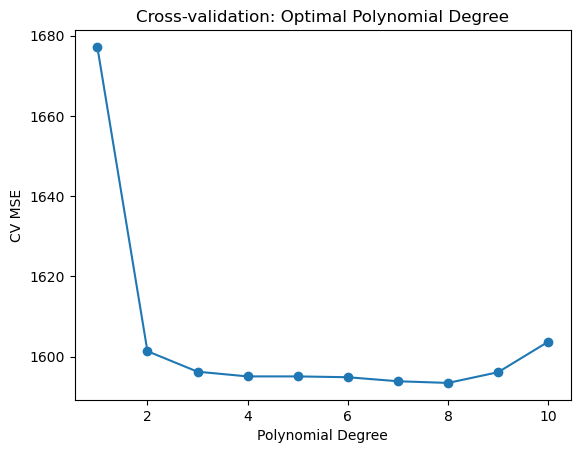

In [6]:
plt.plot(degrees, cv_mse, marker='o')
plt.xlabel("Polynomial Degree")
plt.ylabel("CV MSE")
plt.title("Cross-validation: Optimal Polynomial Degree")
plt.show()


In [ ]:
#Fit Polynomial Model with Optimal Degree
best_poly = PolynomialFeatures(degree=best_degree, include_bias=False)
X_best = best_poly.fit_transform(X)

model_best = LinearRegression().fit(X_best, y)

# Smooth curve
age_grid = np.linspace(wage.age.min(), wage.age.max(), 200).reshape(-1,1)
age_grid_poly = best_poly.transform(age_grid)
pred = model_best.predict(age_grid_poly)


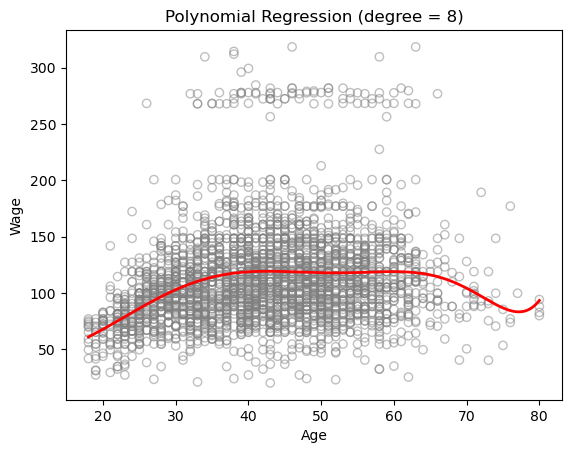

In [8]:
plt.scatter(wage.age, wage.wage, facecolors='none', edgecolors='gray', alpha=0.5)
plt.plot(age_grid, pred, color='red', linewidth=2)
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title(f"Polynomial Regression (degree = {best_degree})")
plt.show()


In [12]:
#ANOVA Comparison (Optional)
models = []
rss_list = []
df_list = []

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_poly = poly.fit_transform(X)
    X_sm = sm.add_constant(X_poly)
    model = sm.OLS(y, X_sm).fit()
    models.append(model)

# Compare models 1 to 10
sm.stats.anova_lm(*models, typ=1)


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,2998.0,5.022216e+06,0.0,NaN,NaN,NaN
1,2997.0,4.793430e+06,1.0,228786.010128,143.518660,2.449925e-32
2,2996.0,4.777674e+06,1.0,15755.693664,9.883629,1.683871e-03
3,2995.0,4.771604e+06,1.0,6070.152124,3.807838,5.110635e-02
4,2994.0,4.770322e+06,1.0,1282.563017,0.804558,3.698061e-01
5,2993.0,4.766389e+06,1.0,3932.257442,2.466726,1.163856e-01
6,2993.0,4.764599e+06,-0.0,1790.485646,-inf,NaN
7,2993.0,4.764136e+06,-0.0,462.454496,-inf,NaN
8,2993.0,4.764981e+06,-0.0,-844.187374,inf,NaN
9,2993.0,4.771202e+06,-0.0,-6221.386732,inf,NaN


(b) Fit a step function to predict wage using age, and perform cross-validation to choose the optimal number of cuts. Make a plot of the fit obtained.

In [10]:
def make_step_function(X, K):
    # Create bins
    bins = np.quantile(X, np.linspace(0,1,K+1))
    return pd.get_dummies(np.digitize(X, bins[1:-1]), drop_first=True)

Ks = range(2, 11)
cv_mse_step = []

for K in Ks:
    X_step = make_step_function(wage.age.values, K)
    
    neg_mse = cross_val_score(LinearRegression(), X_step, y, 
                              scoring='neg_mean_squared_error',
                              cv=kf)
    cv_mse_step.append(-np.mean(neg_mse))

best_K = Ks[np.argmin(cv_mse_step)]
best_K


8

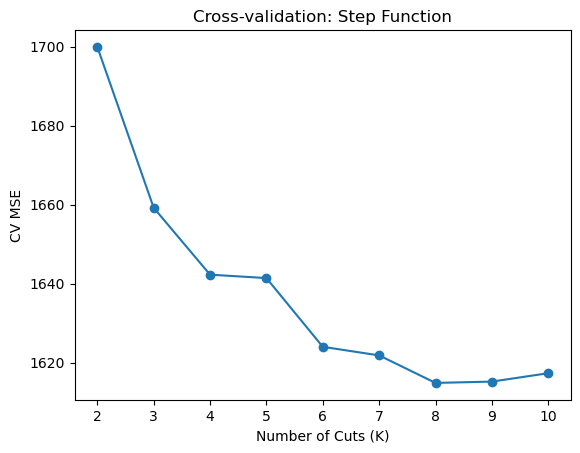

In [11]:
plt.plot(Ks, cv_mse_step, marker='o')
plt.xlabel("Number of Cuts (K)")
plt.ylabel("CV MSE")
plt.title("Cross-validation: Step Function")
plt.show()
